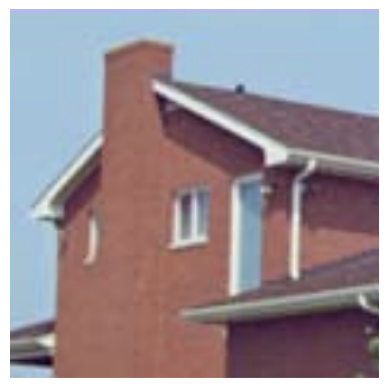

Shape of I: (330, 329, 4)
New shape of I: (330, 329, 3)


In [1]:
import matplotlib.pyplot as plt
import imageio.v2 as imageio

# Load image
I = imageio.imread("house.png")

# Display the image
plt.figure()
plt.imshow(I)
plt.axis("off")
plt.show()

# Shape is (M, N, 4) (4 instead of 3 b/c this is a png (alpha channel))
print(f"Shape of I: {I.shape}")

# Strip alpha channel if it exists
if I.shape[2] == 4:
    I = I[:, :, :3]
    print(f"New shape of I: {I.shape}")

M, N, C = I.shape

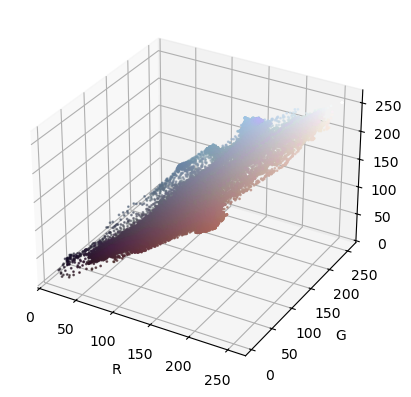

In [2]:
import numpy as np

# I has shape (M, N, 3)
X = I.reshape(M * N, 3)
X = X.astype(np.float64)

# Normalize X to [0, 1] for plotting colours properly
X_norm = X / 255.0

from mpl_toolkits.mplot3d import Axes3D # noqa: F401

fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], s = 1, c = X_norm)
ax.set_xlabel('R')
ax.set_ylabel('G')
ax.set_zlabel('B')
plt.show()

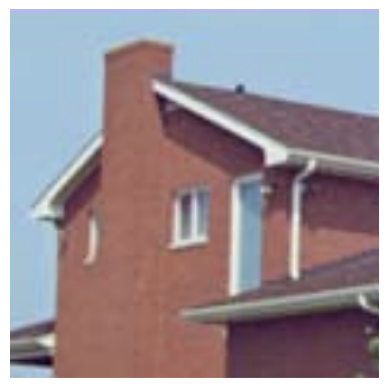

In [3]:
# X_labeld has shape (M*N, 3)
I_labeled = X.reshape(M, N, 3)

plt.figure()
plt.imshow(I_labeled.astype(np.uint8))
plt.axis('off')
plt.show()

In [4]:
c = 2

i = 0
J_history = []
mean_history = []

np.random.seed(42)

mu1 = X[np.random.randint(0, X.shape[0])]
mu2 = X[np.random.randint(0, X.shape[0])]

# print(f"Point 1: {mu1}\nPoint 2: {mu2}")

# Initial means
mean_history.append((mu1.copy(), mu2.copy()))

while (True):
    dist1 = np.sqrt(np.sum((X - mu1)**2, axis = 1))
    dist2 = np.sqrt(np.sum((X - mu2)**2, axis = 1))

    # Assign each pixel to the closest mean
    # 0 for mu1, 1 for mu2
    labels = np.where(dist1 < dist2, 0, 1)

    J = np.sum(dist1[labels == 0]**2) + np.sum(dist2[labels == 1]**2)
    J_history.append(J)

    # Adjust means
    if np.any(labels == 0):
        mu1_new = np.mean(X[labels == 0], axis = 0)
    if np.any(labels == 1):
        mu2_new = np.mean(X[labels == 1], axis = 0)

    if np.array_equal(mu1, mu1_new) and np.array_equal(mu2, mu2_new):
        print(f"Converged at iteration {i}")
        break
    else:
        mu1 = mu1_new
        mu2 = mu2_new
        
        mean_history.append((mu1.copy(), mu2.copy()))
        
        i += 1

# print(f"J:\n {J_history}")
# print(f"means:\n {mean_history}")

Converged at iteration 6


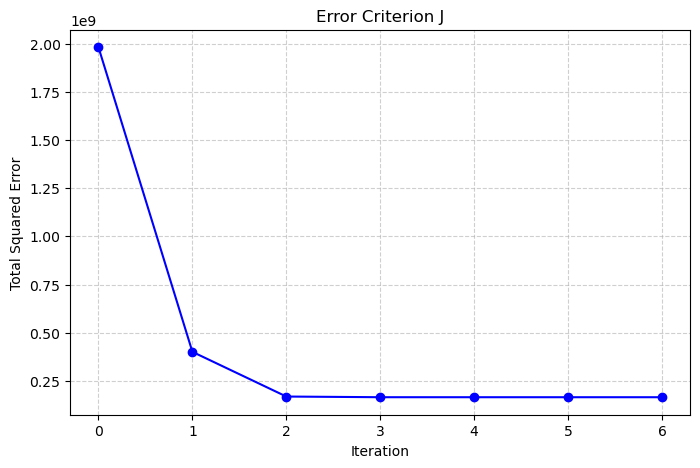

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(range(len(J_history)), J_history, marker = "o", linestyle = "-", color = "b")

plt.title("Error Criterion J")
plt.xlabel("Iteration")
plt.ylabel("Total Squared Error")
plt.grid(True, linestyle = "--", alpha = 0.6)

plt.show()

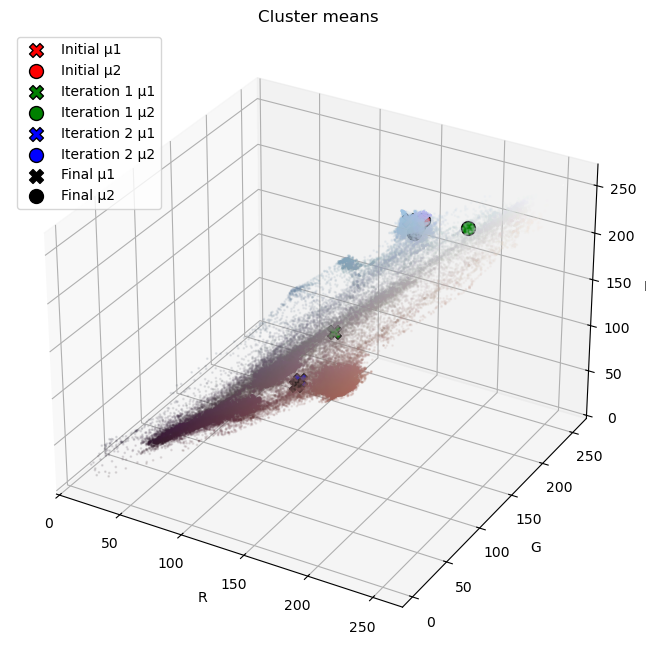

In [31]:
fig = plt.figure(figsize = (10, 8))
ax = fig.add_subplot(111, projection = '3d')

# Plot background pixel cloud with alpha=0.1 to mkae them transparent
ax.scatter(X[:, 0], X[:, 1], X[:, 2], s = 1, c = X_norm, alpha = 0.1)

# Stages to plot
plot_targets = {0: ("Initial", "red"), 1: ("Iteration 1", "Green"), 2: ("Iteration 2", "Blue"), len(mean_history) - 1: ("Final", "black")}

# Plot means
for i in sorted(set(plot_targets.keys())):
    if i < len(mean_history):
        label, colour = plot_targets[i]
        m1, m2 = mean_history[i]

        ax.scatter(m1[0], m1[1], m1[2], s = 100, marker = "X", edgecolors = "black", c = colour, label = f"{label} μ1")
        ax.scatter(m2[0], m2[1], m2[2], s = 100, marker = "o", edgecolors = "black", c = colour, label = f"{label} μ2")

# Format the plot
ax.set_xlabel("R")
ax.set_ylabel("G")
ax.set_zlabel("B")
ax.set_title("Cluster means")
ax.legend()
plt.show()

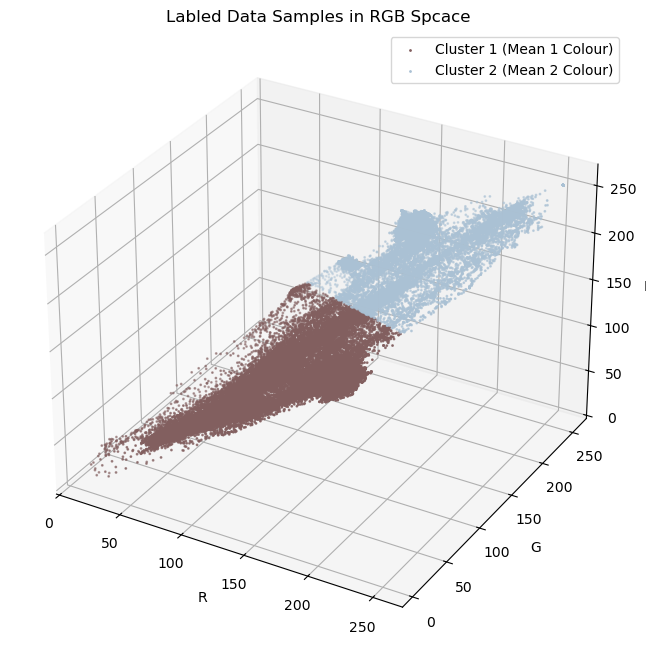

In [6]:
fig = plt.figure(figsize = (10, 8))
ax = fig.add_subplot(111, projection = "3d")

c1_colour = mu1 / 255.0
c2_colour = mu2 / 255.0

ax.scatter(X[labels == 0, 0], X[labels == 0, 1], X[labels == 0, 2], s = 1, color = [c1_colour], label = "Cluster 1 (Mean 1 Colour)")
ax.scatter(X[labels == 1, 0], X[labels == 1, 1], X[labels == 1, 2], s = 1, color = [c2_colour], label = "Cluster 2 (Mean 2 Colour)")

ax.set_xlabel("R")
ax.set_ylabel("G")
ax.set_zlabel("B")
ax.set_title("Labled Data Samples in RGB Spcace")
ax.legend()
plt.show()

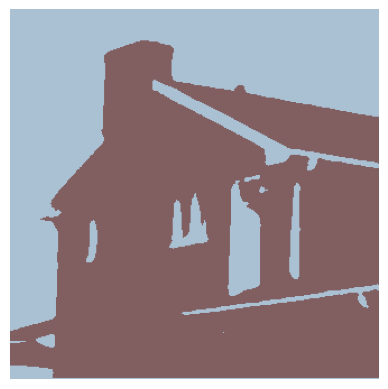

In [7]:
X_labeled = np.zeros_like(X)

X_labeled[labels == 0] = mu1
X_labeled[labels == 1] = mu2

I_labeled = X_labeled.reshape(M, N, 3)

plt.figure()
plt.imshow(I_labeled.astype(np.uint8))
plt.axis("off")
plt.show()

In [32]:
def k_means(X, c, seed):
    k = 0
    np.random.seed(seed)

    random_indicies = np.random.choice(X.shape[0], c, replace = False)
    means = X[random_indicies]

    print(f"Initial means for seed: {seed}\n{means}")

    mean_history = [means.copy()]
    J_history = []

    # Run no more than 100 times
    while (k < 100):
        new_means_list = []

        # Calculate distance from each point to all the means
        distances = np.linalg.norm(X[:, np.newaxis] - means, axis = 2)

        # Assign each pixel to the closest mean (from 0 to c-1)
        labels = np.argmin(distances, axis = 1)

        current_J = 0
        for j in range(c):
            cluster_pixels = X[labels == j]

            if len(cluster_pixels) > 0:
                current_J += np.sum(np.linalg.norm(cluster_pixels - means[j], axis = 1)**2)
                
        J_history.append(current_J)

        for j in range(c):
            if np.any(labels == j):
                # Find the mean colour of each pixel in the cluster
                cluster_mean = np.mean(X[labels == j], axis = 0)
                new_means_list.append(cluster_mean)
            else:
                new_means_list.append(means[j])

        new_means = np.array(new_means_list)

        if np.allclose(means, new_means):
            print(f"Converged at iteration {k}\n")
            break

        means = new_means
        mean_history.append(means.copy())
        k += 1

    return means, labels, J_history, mean_history

run1_mean, run1_labels, run1_J_history, run1_mean_history = k_means(X, 5, 52)
run2_mean, run2_labels, run2_J_history, run2_mean_history = k_means(X, 5, 72) 

Initial means for seed: 52
[[133. 127. 144.]
 [121. 105. 100.]
 [118.  95.  99.]
 [165. 114. 111.]
 [159. 105.  96.]]
Converged at iteration 19

Initial means for seed: 72
[[151. 103.  91.]
 [121.  82.  81.]
 [164. 197. 214.]
 [140. 102.  99.]
 [159. 141. 147.]]
Converged at iteration 16



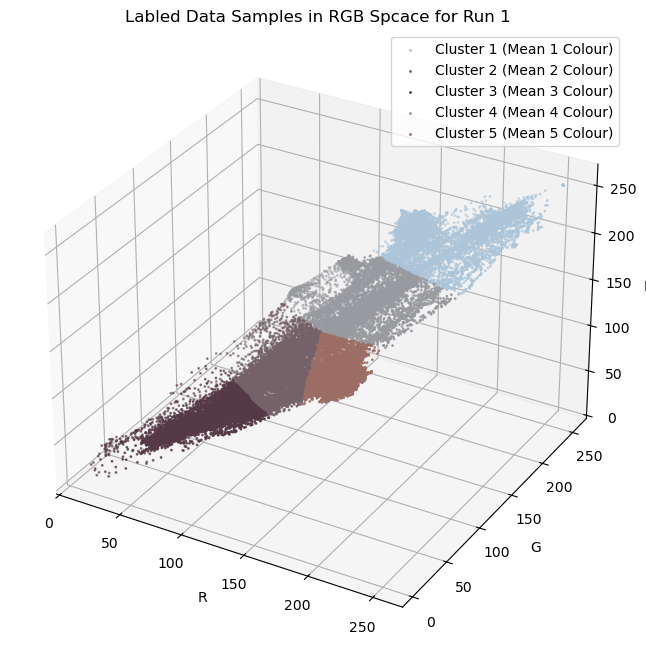

In [16]:
fig = plt.figure(figsize = (10, 8))
ax = fig.add_subplot(111, projection = "3d")

run1_c1_colour = run1_mean[0] / 255.0
run1_c2_colour = run1_mean[1] / 255.0
run1_c3_colour = run1_mean[2] / 255.0
run1_c4_colour = run1_mean[3] / 255.0
run1_c5_colour = run1_mean[4] / 255.0

ax.scatter(X[run1_labels == 0, 0], X[run1_labels == 0, 1], X[run1_labels == 0, 2], s = 1, color = [run1_c1_colour], label = "Cluster 1 (Mean 1 Colour)")
ax.scatter(X[run1_labels == 1, 0], X[run1_labels == 1, 1], X[run1_labels == 1, 2], s = 1, color = [run1_c2_colour], label = "Cluster 2 (Mean 2 Colour)")
ax.scatter(X[run1_labels == 2, 0], X[run1_labels == 2, 1], X[run1_labels == 2, 2], s = 1, color = [run1_c3_colour], label = "Cluster 3 (Mean 3 Colour)")
ax.scatter(X[run1_labels == 3, 0], X[run1_labels == 3, 1], X[run1_labels == 3, 2], s = 1, color = [run1_c4_colour], label = "Cluster 4 (Mean 4 Colour)")
ax.scatter(X[run1_labels == 4, 0], X[run1_labels == 4, 1], X[run1_labels == 4, 2], s = 1, color = [run1_c5_colour], label = "Cluster 5 (Mean 5 Colour)")

ax.set_xlabel("R")
ax.set_ylabel("G")
ax.set_zlabel("B")
ax.set_title("Labled Data Samples in RGB Spcace for Run 1")
ax.legend()
plt.show()

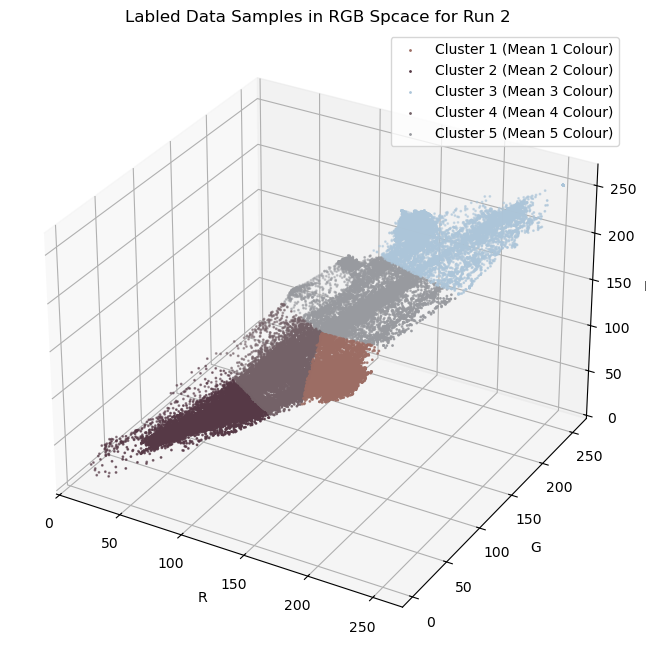

In [17]:
fig = plt.figure(figsize = (10, 8))
ax = fig.add_subplot(111, projection = "3d")

run2_c1_colour = run2_mean[0] / 255.0
run2_c2_colour = run2_mean[1] / 255.0
run2_c3_colour = run2_mean[2] / 255.0
run2_c4_colour = run2_mean[3] / 255.0
run2_c5_colour = run2_mean[4] / 255.0

ax.scatter(X[run2_labels == 0, 0], X[run2_labels == 0, 1], X[run2_labels == 0, 2], s = 1, color = [run2_c1_colour], label = "Cluster 1 (Mean 1 Colour)")
ax.scatter(X[run2_labels == 1, 0], X[run2_labels == 1, 1], X[run2_labels == 1, 2], s = 1, color = [run2_c2_colour], label = "Cluster 2 (Mean 2 Colour)")
ax.scatter(X[run2_labels == 2, 0], X[run2_labels == 2, 1], X[run2_labels == 2, 2], s = 1, color = [run2_c3_colour], label = "Cluster 3 (Mean 3 Colour)")
ax.scatter(X[run2_labels == 3, 0], X[run2_labels == 3, 1], X[run2_labels == 3, 2], s = 1, color = [run2_c4_colour], label = "Cluster 4 (Mean 4 Colour)")
ax.scatter(X[run2_labels == 4, 0], X[run2_labels == 4, 1], X[run2_labels == 4, 2], s = 1, color = [run2_c5_colour], label = "Cluster 5 (Mean 5 Colour)")

ax.set_xlabel("R")
ax.set_ylabel("G")
ax.set_zlabel("B")
ax.set_title("Labled Data Samples in RGB Spcace for Run 2")
ax.legend()
plt.show()

In [23]:
def xb_index(X, means, labels):
    N = X.shape[0]
    c = len(means)

    # Numerator
    sum_squared_error = 0
    for j in range(c):
        cluster_pixels = X[labels == j]
        if len(cluster_pixels) > 0:
            sum_squared_error += np.sum(np.linalg.norm(cluster_pixels - means[j], axis = 1)**2)

    min_distance_squared = float("inf")
    for i in range(c):
        for j in range(i + 1, c):
            distance_squared = np.sum((means[i] - means[j])**2)

            if distance_squared < min_distance_squared:
                min_distance_squared = distance_squared
                
    denominator = N * min_distance_squared

    return sum_squared_error / denominator

xb_run1 = xb_index(X, run1_mean, run1_labels)
xb_run2 = xb_index(X, run2_mean, run2_labels)

print(f"XB Index Run 1: {xb_run1}")
print(f"XB Index Run 2: {xb_run2}")

XB Index Run 1: 0.21409389154845412
XB Index Run 2: 0.21420927915557106
